# Project EdTech - Online Education

# Problem Statement

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023, with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc., it is now preferable to traditional education.

The online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like:

 The customer interacts with the marketing front on social media or other online platforms.
 The customer browses the website/app and downloads the brochure.
 The customer connects through emails for more information.
The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

# Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate the resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:

- Analyze and build an ML model to help identify which leads are more likely to convert to paid customers.

- Find the factors driving the lead conversion process.

- Create a profile of the leads who are likely to convert.

# Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.

Data Dictionary

ID: ID of the lead

age: Age of the lead

current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'

first_interaction: How did the lead first interact with ExtraaLearn. Values include 'Website', 'Mobile App'

profile_completed: What percentage of the profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)

website_visits: How many times has a lead visited the website

time_spent_on_website: Total time spent on the website

page_views_per_visit: Average number of pages on the website viewed during the visits.

last_activity: Last interaction between the lead and ExtraaLearn.

Email Activity: Seeking for details about the program through email, Representative shared information with a lead like a brochure of program, etc
Phone Activity: Had a Phone Conversation with a representative, Had conversation over SMS with a representative, etc
Website Activity: Interacted on live chat with a representative, Updated profile on the website, etc
print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.

print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.

digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.

educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.

referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.

status: Flag indicating whether the lead was converted to a paid customer or not.


In [ ]:
import warnings

warnings.filterwarnings("ignore")
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)

In [ ]:
#Importing the necessary libraries for manipulating the data

import pandas as pd
import numpy as np

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# To build model for prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

# To tune different models
from sklearn.model_selection import GridSearchCV


# To get diferent metric scores
import sklearn.metrics as metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)

In [ ]:
#Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

#Setting the file path
file_path = '/content/drive/My Drive/ExtraaLearn.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Importing pandas as the necessary library
import pandas as pd

#Loading the dataset
data = pd.read_csv('/content/drive/My Drive/ExtraaLearn.csv')

#To display the first five rows
data.head(5)

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.86100,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.32000,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.07400,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.05700,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.91400,Email Activity,No,No,No,No,No,0


In [ ]:
# To display the last 5 rows of the dataset
data.tail(5)

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
4607,EXT4608,35,Unemployed,Mobile App,Medium,15,360,2.17000,Phone Activity,No,No,No,Yes,No,0
4608,EXT4609,55,Professional,Mobile App,Medium,8,2327,5.39300,Email Activity,No,No,No,No,No,0
4609,EXT4610,58,Professional,Website,High,2,212,2.69200,Email Activity,No,No,No,No,No,1
4610,EXT4611,57,Professional,Mobile App,Medium,1,154,3.87900,Website Activity,Yes,No,No,No,No,0
4611,EXT4612,55,Professional,Website,Medium,4,2290,2.07500,Phone Activity,No,No,No,No,No,0


In [ ]:
#Understand the shape of the data
data.shape

(4612, 15)

In [ ]:
#Checking for the duplicates
data.duplicated().sum()

0

# Exploratroy Data Analaysis (EDA)

In [ ]:
#For statistical summary of the data
data.describe()

,age,website_visits,time_spent_on_website,page_views_per_visit,status
count,4612.00000,4612.00000,4612.00000,4612.00000,4612.00000
mean,46.20121,3.56678,724.01127,3.02613,0.29857
std,13.16145,2.82913,743.82868,1.96812,0.45768
min,18.00000,0.00000,0.00000,0.00000,0.00000
25%,36.00000,2.00000,148.75000,2.07775,0.00000
50%,51.00000,3.00000,376.00000,2.79200,0.00000
75%,57.00000,5.00000,1336.75000,3.75625,1.00000
max,63.00000,30.00000,2537.00000,18.43400,1.00000


In [ ]:
# Making a list of all catrgorical variables
cat_col = list(data.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

ID
EXT001     1
EXT2884    1
EXT3080    1
EXT3079    1
EXT3078    1
          ..
EXT1537    1
EXT1536    1
EXT1535    1
EXT1534    1
EXT4612    1
Name: count, Length: 4612, dtype: int64
--------------------------------------------------
current_occupation
Professional    2616
Unemployed      1441
Student          555
Name: count, dtype: int64
--------------------------------------------------
first_interaction
Website       2542
Mobile App    2070
Name: count, dtype: int64
--------------------------------------------------
profile_completed
High      2264
Medium    2241
Low        107
Name: count, dtype: int64
--------------------------------------------------
last_activity
Email Activity      2278
Phone Activity      1234
Website Activity    1100
Name: count, dtype: int64
--------------------------------------------------
print_media_type1
No     4115
Yes     497
Name: count, dtype: int64
--------------------------------------------------
print_media_type2
No     4379
Yes     233
Name

In [ ]:
# Checking the number of unique values in the 'ID' column
data["ID"].nunique()

4612

In [ ]:
#Drop the ID columns because its not meaningful for the analysis
data.drop(["ID"], axis=1, inplace=True)

# Univariate Analysis

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="red", linestyle="-"
    )  # Add median to the histogram

**Observation on Age feature**

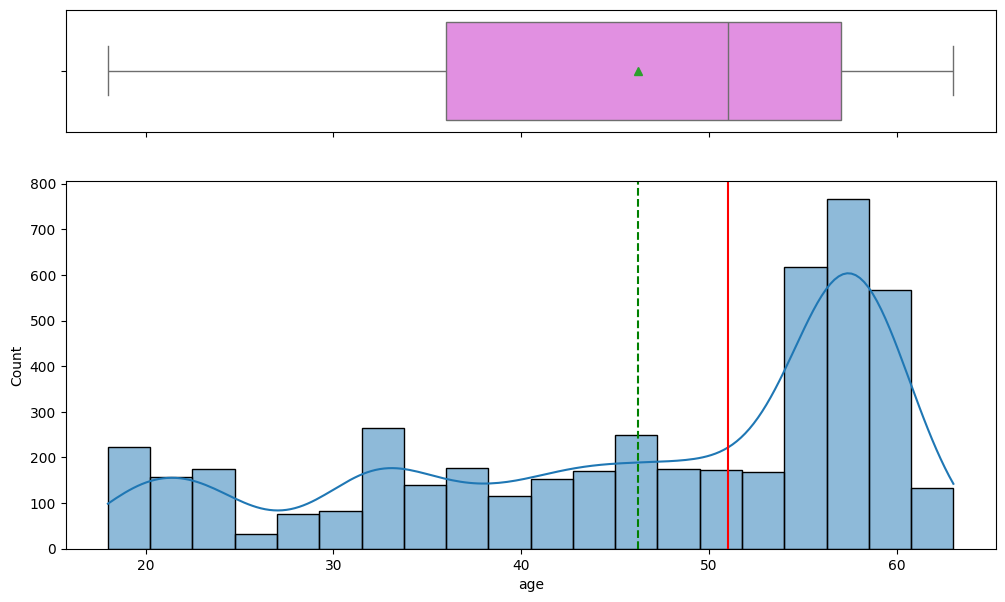

In [ ]:
#Calling the function for the 'age' feature
histogram_boxplot(data, feature='age', kde=True, bins=20)

This histogram and boxplot of age data shows a bimodal distribution with peaks around ages 20-22 and 55-60. The main concentration (interquartile range) is between 42-55 (purple box), with the median (green triangle) at approximately 45. The data spans roughly from 18 to 65 years old, with significantly higher frequency counts in the older age range (55-60) where counts reach nearly 800 individuals.

**Observation on the Website Visits**

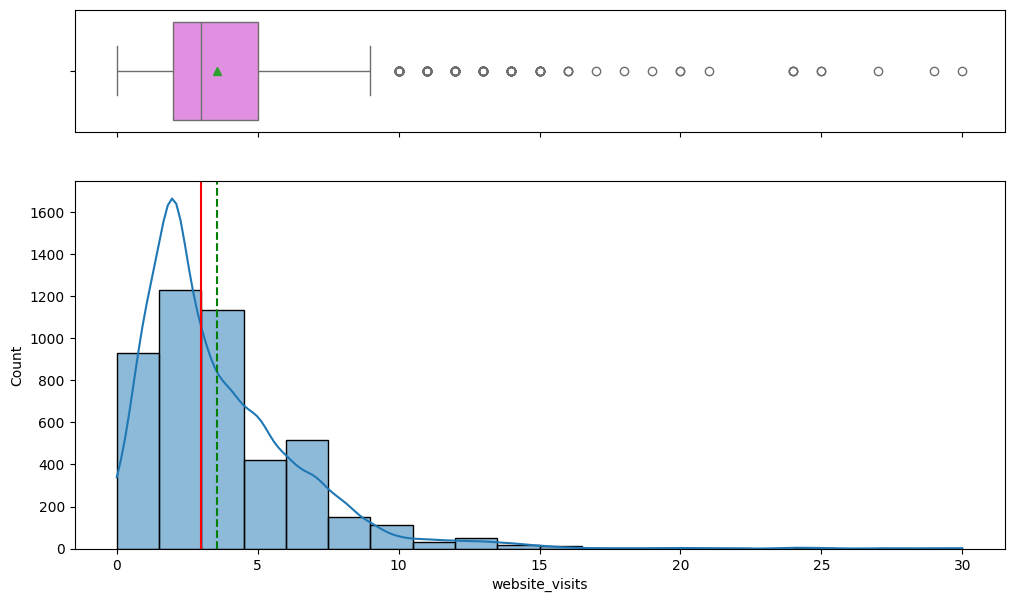

In [ ]:
# Plotting the histogram_boxplot for 'website_visits'
histogram_boxplot(data, feature='website_visits', kde=True, bins=20)

The histogram shows website visits are positively skewed, with most users visiting 2-4 times (peak around 2-3 visits). The boxplot indicates the median (green triangle) is around 4 visits, with numerous outliers beyond 10 visits. The count (y-axis) represents the number of users with that specific number of visits -  approximately 1,200 users visited the website 2-3 times.

In [ ]:
# Checking how many leads have not visited web-site
data[data["website_visits"] == 0].shape

(174, 14)

174 leads who haven't visited the website.

Observations on number of time spent on website

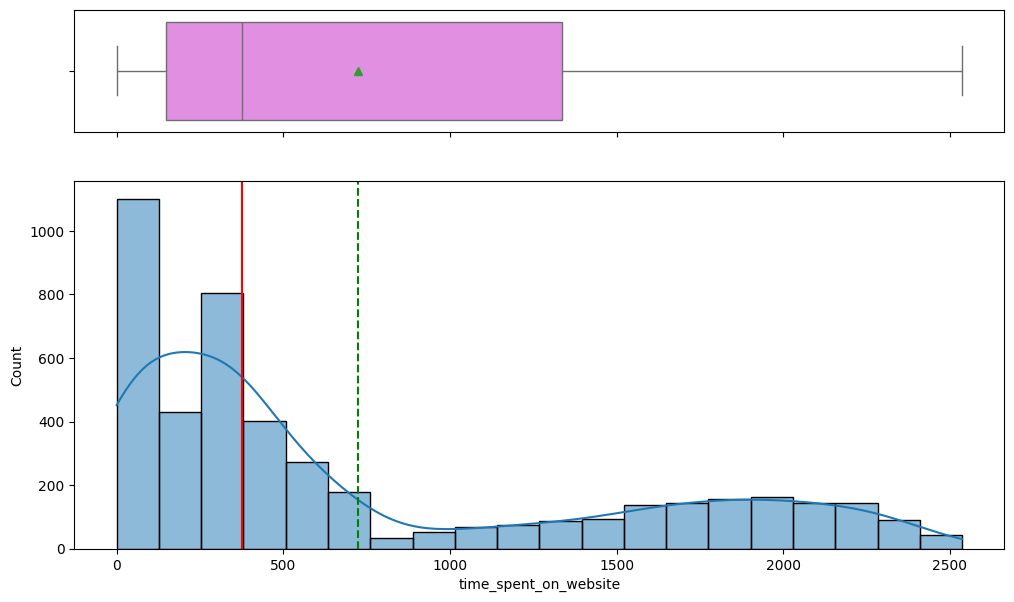

In [ ]:
# Plotting the histogram_boxplot for 'time_spent_on_website'
histogram_boxplot(data, feature='time_spent_on_website', kde=True, bins=20)

The graph shows time spent on website has a bimodal distribution with most users spending less than 500 seconds (highest counts at 0-100 seconds), but a smaller group spending 1500-2000 seconds. The boxplot reveals a wide interquartile range (purple box) with the median (green triangle) at approximately 700 seconds. The red line represents a threshold or mean value around 400 seconds, distinguishing between short-term and more engaged visitors.

**Observations on number of page views per visit**

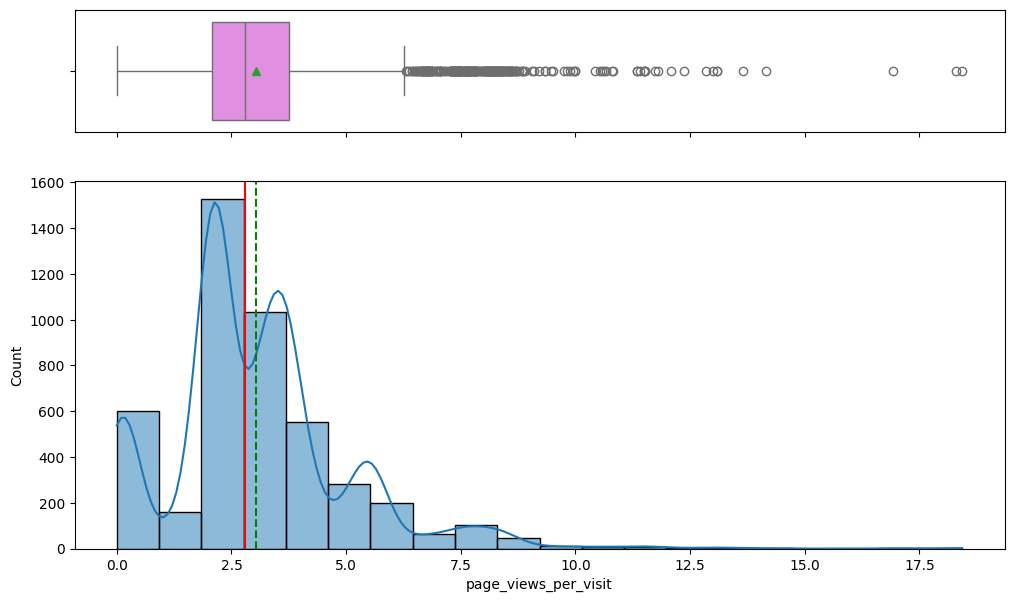

In [ ]:
# Plotting the histogram_boxplot for 'page_views_per_visit'
histogram_boxplot(data, feature='page_views_per_visit', kde=True, bins=20)

The histogram shows page views per visit has a multimodal distribution with primary peaks at 2-3 pages (highest count ~1500 users) and 3-4 pages (count ~1000 users). The boxplot indicates the median (green triangle) is around 3 pages per visit, with the interquartile range (purple box) between approximately 2-4 pages. Multiple outliers extend beyond 7 pages, showing a small segment of users view significantly more pages per visit.

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

**Observation on current occupation**

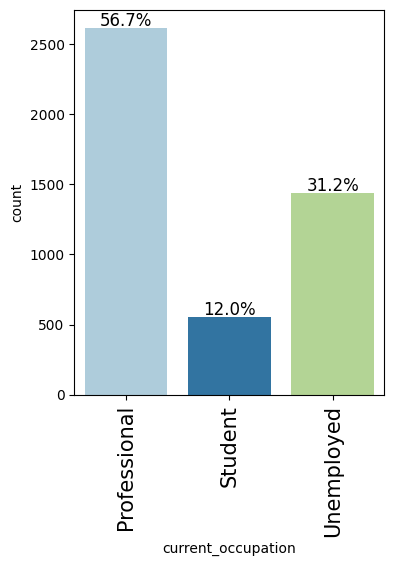

In [ ]:
labeled_barplot(data, "current_occupation", perc=True)

**Observation on number of first interaction**

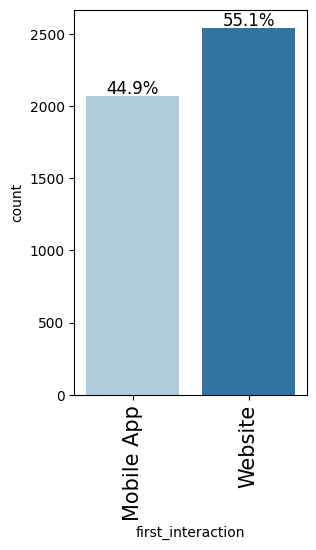

In [ ]:
labeled_barplot(data,feature='first_interaction', perc=True, n=None)

**Observations on profile completed**

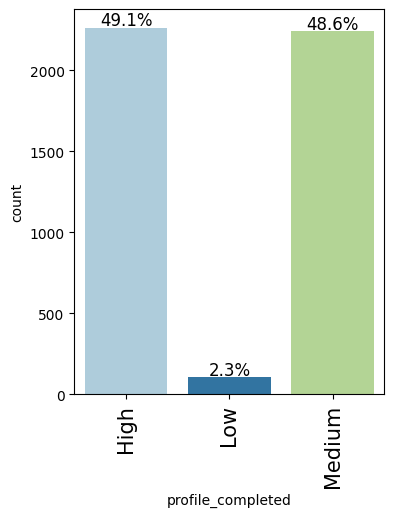

In [ ]:
labeled_barplot(data, feature='profile_completed', perc=True, n=None)

**Observations on last activity**

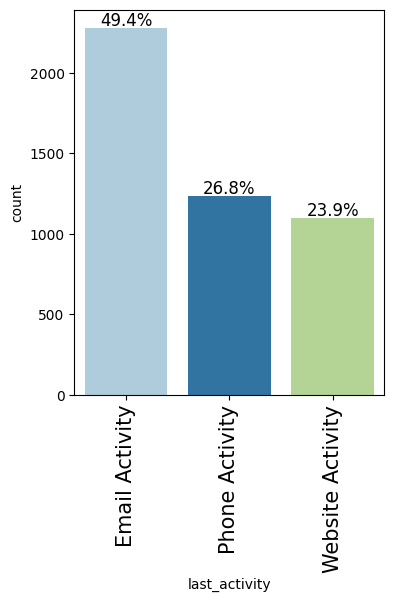

In [ ]:
labeled_barplot(data, feature='last_activity', perc=True, n=None)

**Observations on print media type1**

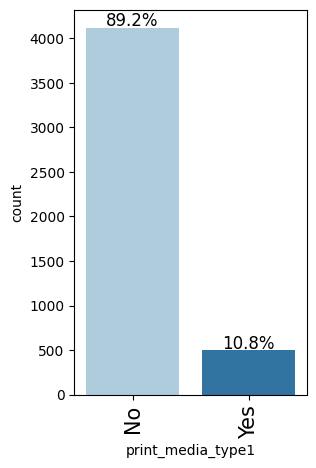

In [ ]:
labeled_barplot(data, feature='print_media_type1', perc=True, n=None)

 89.2% of the leads in the dataset did not see an advertisement of ExtraaLearn in the newspaper. Whereas, 10.85% did.

**Observations on print media type2**

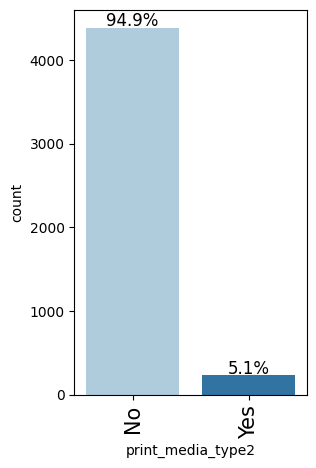

In [ ]:
labeled_barplot(data, feature='print_media_type2', perc=True, n=None)

94.9% of the leads in your dataset did not see an advertisement of ExtraaLearn in the magazine. Whereas, 5.1% did.

**Observations on digital media**

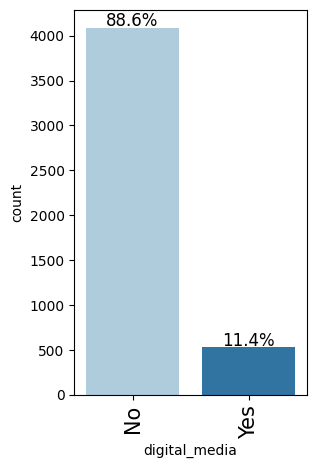

In [ ]:
labeled_barplot(data, feature='digital_media', perc=True, n=None)

88.6% of the leads in the dataset did not see an advertisement of ExtraaLearn on digital platforms (such as social media, websites, etc.). Whereas, 11.45 did.

**Observations on educational channels**

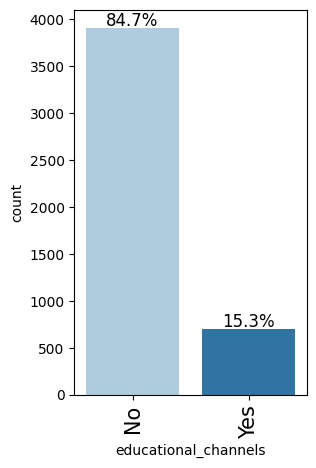

In [ ]:
labeled_barplot(data, feature='educational_channels', perc=True, n=None)

84.7% of the leads in the dataset did not hear about ExtraaLearn through educational channels (like online forums, educational websites, etc.). Whereas, 15.3% did.

**Observations on referral**

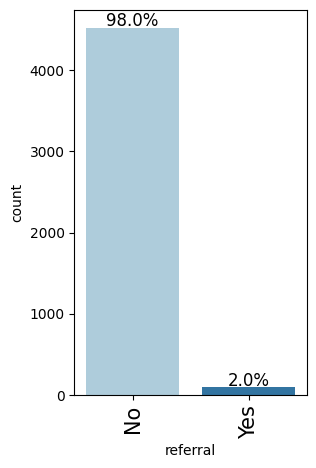

In [ ]:
labeled_barplot(data, feature='referral', perc=True, n=None)

98% of the leads in the dataset did not hear about ExtraaLearn through referrals (i.e., through a reference from someone else).Whereas, 2% did.

**Observations on status**

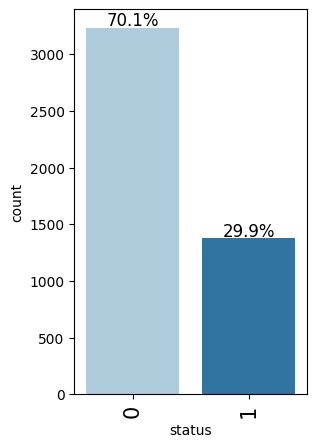

In [ ]:
labeled_barplot(data, feature='status', perc=True, n=None)

70.1% of the leads in the dataset did not convert to paid customers (status = 0). Whereas, 29.9% of the leads did convert to paid customers (status = 1).

# Bivariate Analysis

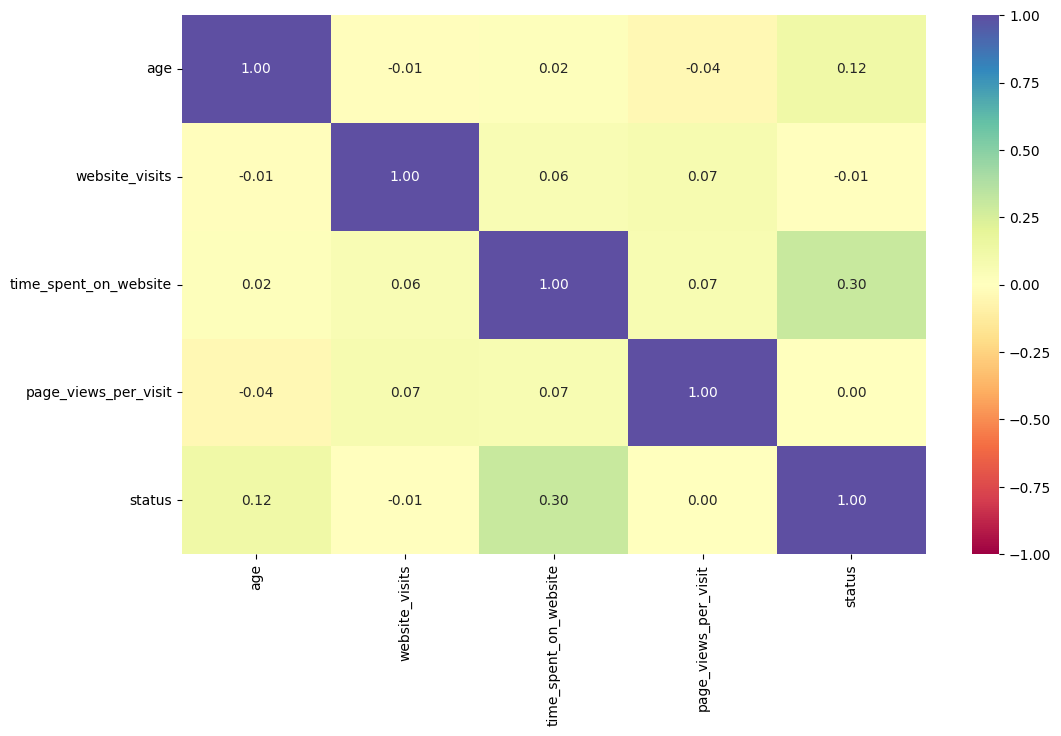

In [ ]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 7))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

This correlation matrix shows mostly weak relationships between variables. The strongest correlation (0.30) exists between time_spent_on_website and status, suggesting moderate association between how long users stay on the site and their status. Other correlations are minimal: website visits shows weak positive correlations (0.06-0.07) with time spent and page views; age has negligible correlations with most variables except a slight positive relationship (0.12) with status. Overall, the variables appear largely independent of each other, with the time-status relationship being the only notable association.

Creating functions to help further analysis.

In [ ]:
#function to plot distributions with respect to target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="green",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

Note: Leads may have varying expectations regarding the outcome of the course, and their current job or profession could significantly influence their decision to enroll in the program.

status                 0     1   All
current_occupation                  
All                 3235  1377  4612
Professional        1687   929  2616
Unemployed          1058   383  1441
Student              490    65   555
------------------------------------------------------------------------------------------------------------------------


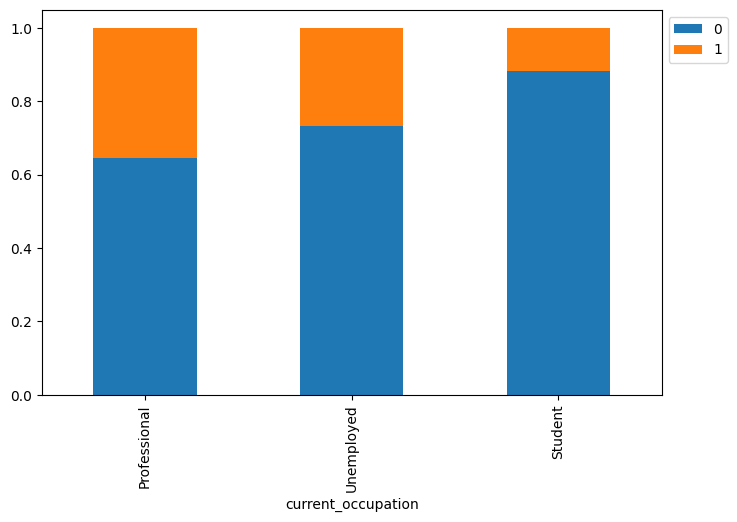

In [ ]:
stacked_barplot(data, "current_occupation", "status")

The stacked bar plot provides a detailed breakdown of the conversion status of leads across different occupations. For the entire dataset, there are a total of 4612 leads, with 3235 leads not converting to paid customers and 1377 leads successfully converting.

Breaking this down by occupation:

Among the Professional leads, there are 2616 individuals in total. Out of these, 1687 did not convert to a paid customer, while 929 did convert.
For the Unemployed leads, there are 1441 individuals in total. Of these, 1058 did not convert, and 383 leads successfully converted into paid customers.
Among Student leads, the total number of leads is 555. However, the conversion rate is the lowest in this category, with only 65 students converting to paid customers, while 490 did not.

The data suggests that Professional leads have a higher conversion rate compared to Unemployed and Student leads. The majority of leads across all occupation categories have not converted to paid customers, with Students showing the lowest conversion rate of all occupations.

This information could help ExtraaLearn tailor its marketing and engagement strategies to target professionals more effectively, who seem more likely to convert compared to unemployed or student leads.

**Age could be an important factor for distinguishing between different types of leads**.

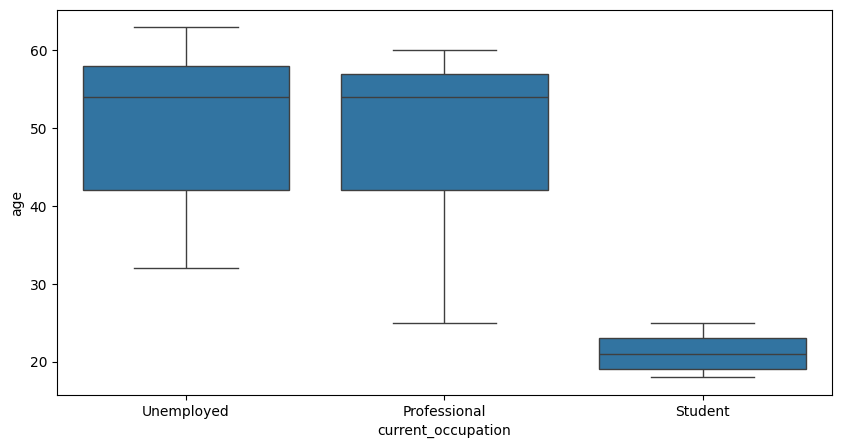

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data = data, x = data["current_occupation"], y = data["age"])
plt.show()

The boxplot shows clear age differences across occupations. Unemployed and Professional groups have similar age distributions with medians around 53-55 years and ranges from early 30s to early 60s. In contrast, the Student group has a substantially lower median age of about 21 years with a narrower range (18-25 years), displaying a clear separation from the other two occupation categories.

In [ ]:
#Groupby with Current occupation
data.groupby(["current_occupation"])["age"].describe()

,count,mean,std,min,25%,50%,75%,max
current_occupation,,,,,,,,
Professional,2616.00000,49.34748,9.89074,25.00000,42.00000,54.00000,57.00000,60.00000
Student,555.00000,21.14414,2.00111,18.00000,19.00000,21.00000,23.00000,25.00000
Unemployed,1441.00000,50.14018,9.99950,32.00000,42.00000,54.00000,58.00000,63.00000


**The initial contact with leads should be engaging and convincing. Let's examine whether the channels used for the first interaction influence the lead conversion rate**.

status                0     1   All
first_interaction                  
All                3235  1377  4612
Website            1383  1159  2542
Mobile App         1852   218  2070
------------------------------------------------------------------------------------------------------------------------


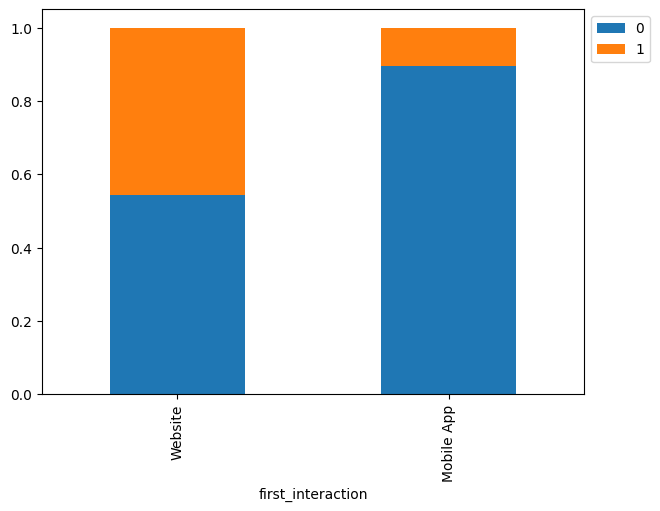

In [ ]:
stacked_barplot(data, predictor='first_interaction', target='status')

45.6% of leads who interacted through the website converted into paid customers. This is a relatively high conversion rate, suggesting that leads who engage via the website are more likely to convert. Only 10.5% of leads who interacted through the mobile app converted. This is much lower compared to the website, suggesting that leads who engage via the mobile app are less likely to convert.

**Reccommendations on this part:**


Engagement via Website seems to lead to higher conversion rates. ExtraaLearn could consider optimizing its website experience (e.g., simplifying the sign-up process, providing clearer course details, or offering personalized follow-ups) to further boost conversions.
Mobile App Engagement appears to have a much lower conversion rate. This might suggest a need to revisit the mobile app interface or improve its user experience to drive higher engagement and conversion.
Conversion Improvement: ExtraaLearn could experiment with targeted strategies for each channel. For example, they could enhance mobile app features, improve user guidance, or even try integrating website-style engagement features (like live chats or clearer calls to action) into the mobile app.

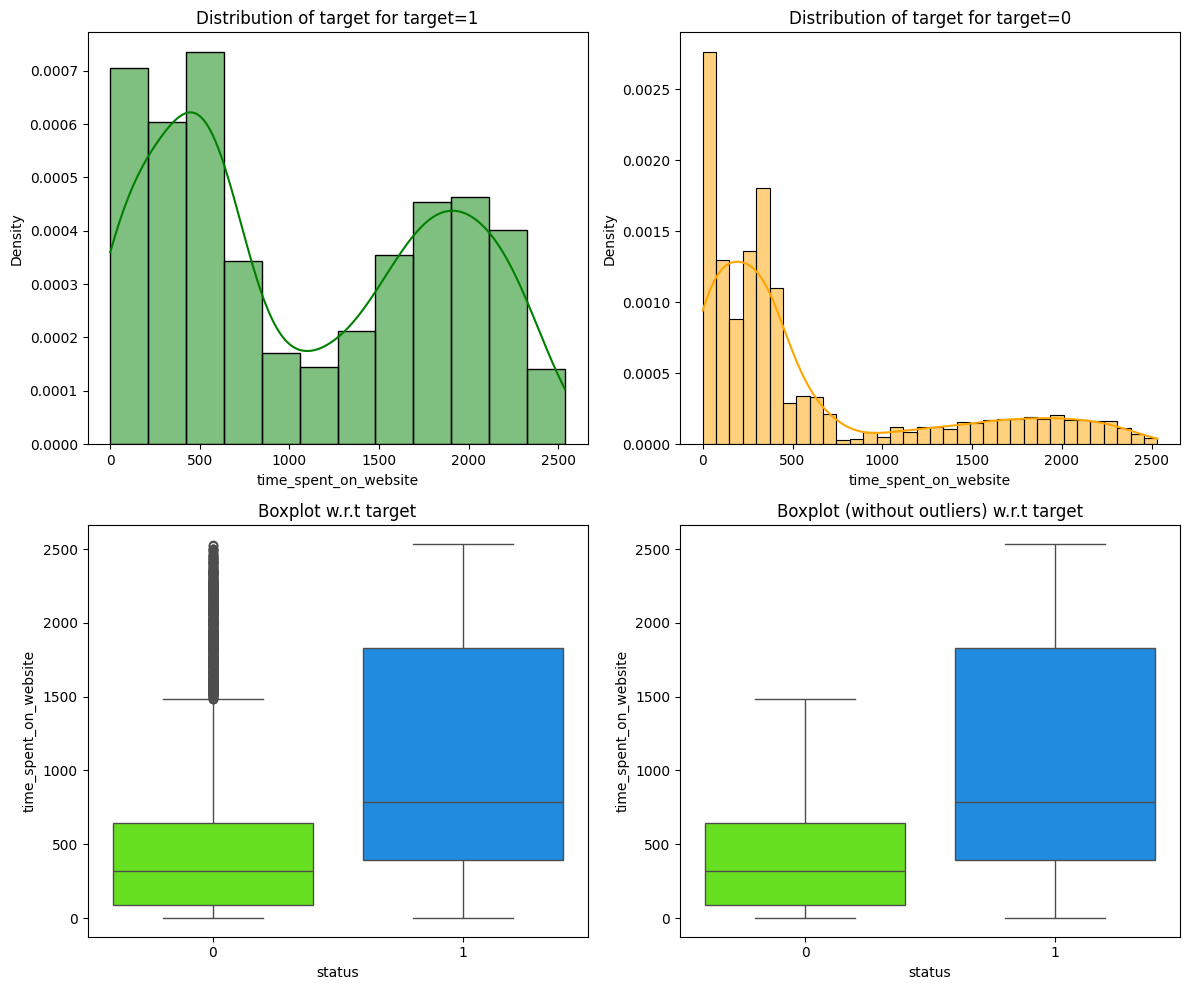

In [ ]:
distribution_plot_wrt_target(data, "time_spent_on_website", "status") #checking distribution for time spent on website with status - because website is the biggest driver of conversions.

The distribution plots reveal significant differences in time spent between converted (status=1) and non-converted (status=0) users. Converted users (blue boxplot) spend substantially more time on the website (median ~800 seconds) with a bimodal distribution showing peaks at both 300-600 seconds and 1700-2000 seconds. Non-converted users (green boxplot) spend much less time (median ~300 seconds) with a heavily right-skewed distribution concentrated below 500 seconds. This strong relationship supports the comment that "website is the biggest driver of conversions" as longer engagement clearly correlates with conversion status.

In [ ]:
# checking the median value
data.groupby(["status"])["time_spent_on_website"].median()

,time_spent_on_website
status,
0,317.00000
1,789.00000


**Conducting a similar analysis for the amount of time spent on the website and the number of pages viewed per visit**.

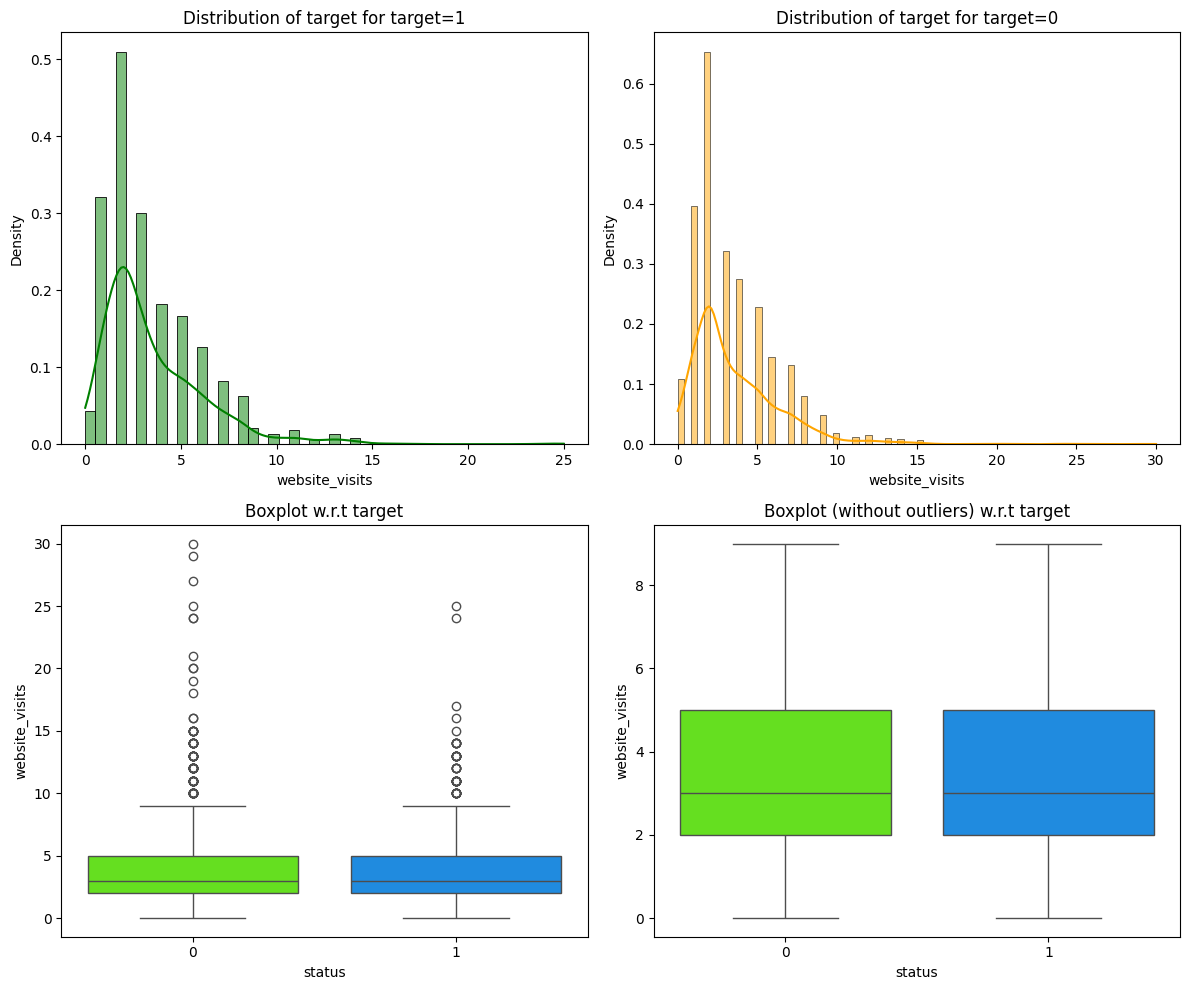

In [ ]:
distribution_plot_wrt_target(data, "website_visits", "status") #for website visits and status

The above graphs show the distribution of website visits across two groups (status 0 and 1). Both groups have similar visit patterns with most users visiting fewer than 5 times, and the distributions are positively skewed with some outliers visiting up to 30 times. The boxplots suggest that the median number of visits is around 3, with slightly higher variation in the outlier-removed plot.

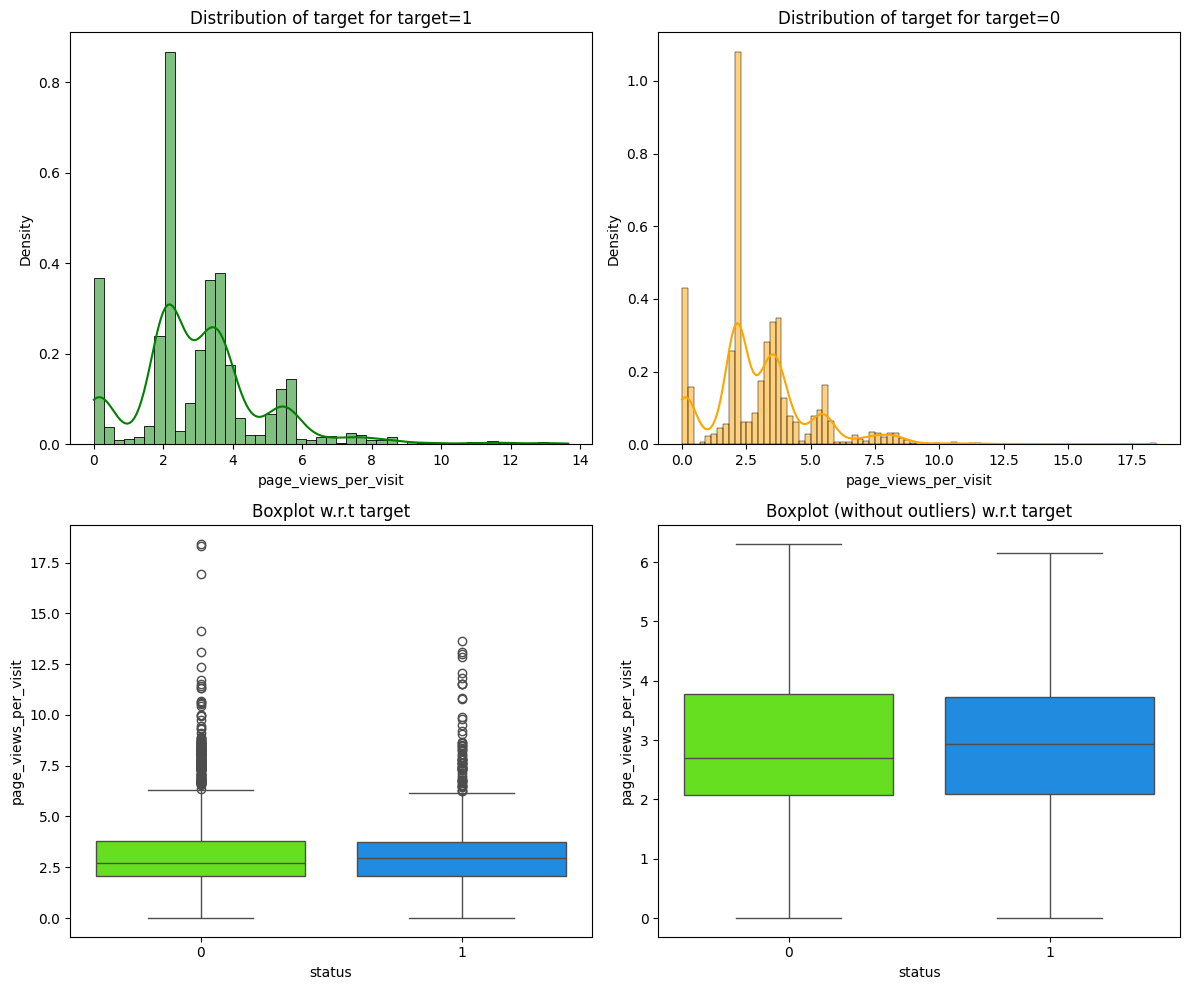

In [ ]:
distribution_plot_wrt_target(data, "page_views_per_visit", "status") #for page views per visit and status

These graphs show the distribution of page views per visit across two status groups (0 and 1). Both groups exhibit multimodal distributions with peaks around 2-4 page views per visit. The boxplots indicate similar median values of approximately 3 pages per visit for both groups, with numerous outliers reaching up to 18 page views in some cases.

**People browsing the website or the mobile app are generally required to create a profile by sharing their personal details before they can access more information. Let's see if the profile completion level has an impact on lead status**

status                0     1   All
profile_completed                  
All                3235  1377  4612
High               1318   946  2264
Medium             1818   423  2241
Low                  99     8   107
------------------------------------------------------------------------------------------------------------------------


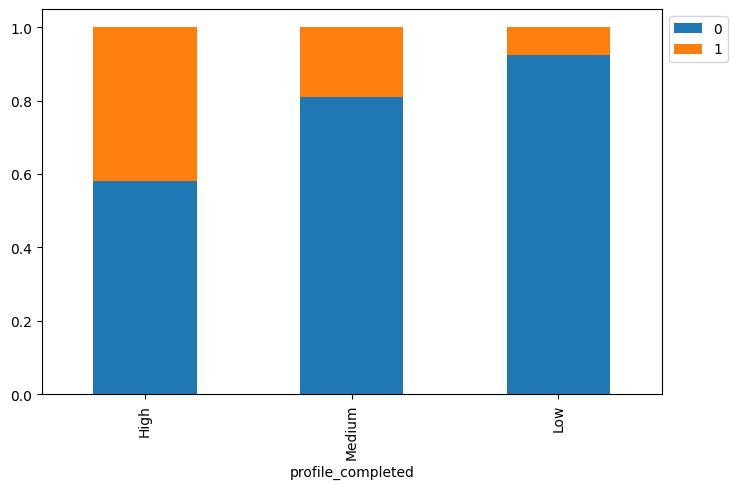

In [ ]:
stacked_barplot(data, "profile_completed", "status") #checking profile completion

The output shows that leads who completed a higher percentage of their profile (High) had a significantly higher conversion rate, with 946 conversions out of 2264 leads, while those with low profile completion (Low) had very few conversions, indicating that profile completion positively influences conversion likelihood.

**After a lead shares their information by creating a profile, there may be interactions between the lead and the company to proceed with the process of enrollment. Let's see how the last activity impacts lead conversion status**

status               0     1   All
last_activity                     
All               3235  1377  4612
Email Activity    1587   691  2278
Website Activity   677   423  1100
Phone Activity     971   263  1234
------------------------------------------------------------------------------------------------------------------------


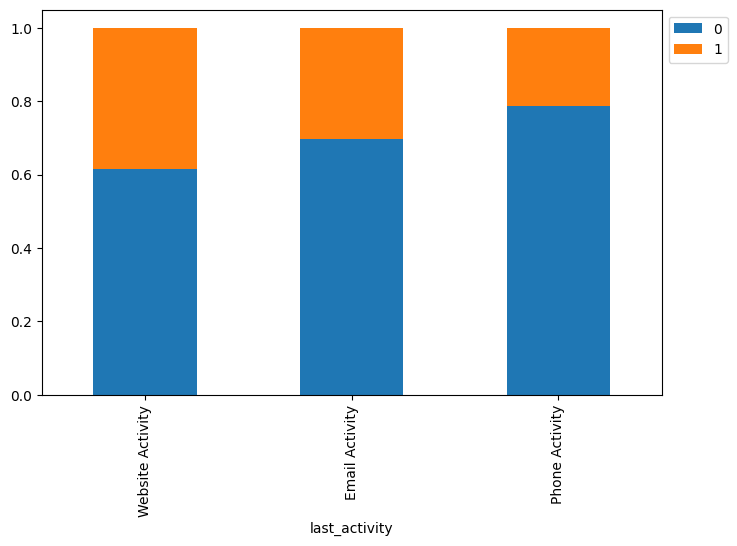

In [ ]:
stacked_barplot(data, "last_activity", "status") #checking the last activity

Leads who engaged in Website Activity had the highest conversion rate (38.5%), suggesting that website interactions might be more effective for conversion compared to email or phone activities.

**How advertisement and referrals impact the lead status**

status                0     1   All
print_media_type1                  
All                3235  1377  4612
No                 2897  1218  4115
Yes                 338   159   497
------------------------------------------------------------------------------------------------------------------------


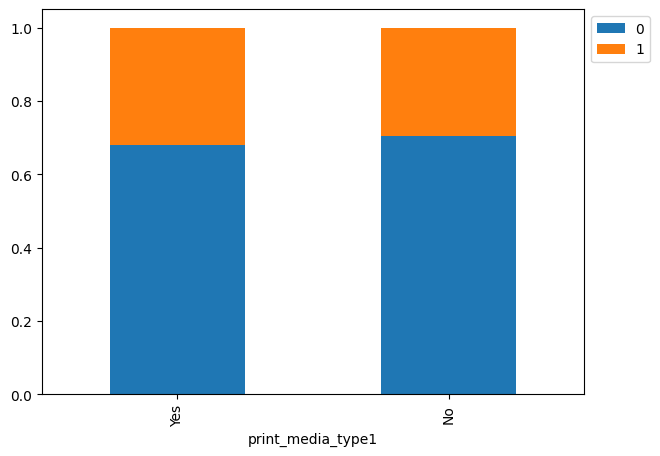

In [ ]:
stacked_barplot(data, "print_media_type1", "status") #for print media type1

The output shows that leads who saw the ad in the newspaper had a higher conversion rate (159 out of 497, or 32.0%) compared to those who did not see the ad (1218 out of 4115, or 29.6%), suggesting that exposure to the newspaper ad has a slightly positive impact on conversion.

status                0     1   All
print_media_type2                  
All                3235  1377  4612
No                 3077  1302  4379
Yes                 158    75   233
------------------------------------------------------------------------------------------------------------------------


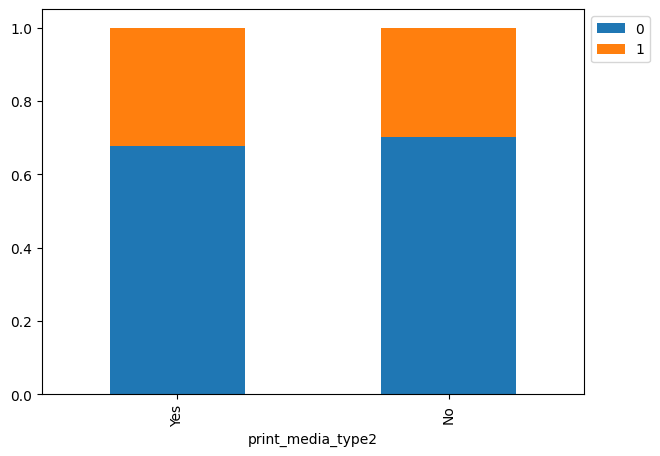

In [ ]:
stacked_barplot(data, "print_media_type2", "status") #checking for print media type2

Leads who saw the ad in the magazine those who did not see the ad (1302 out of 4379, or 29.7%), indicating a marginal positive effect of magazine exposure on conversion.

status            0     1   All
digital_media                  
All            3235  1377  4612
No             2876  1209  4085
Yes             359   168   527
------------------------------------------------------------------------------------------------------------------------


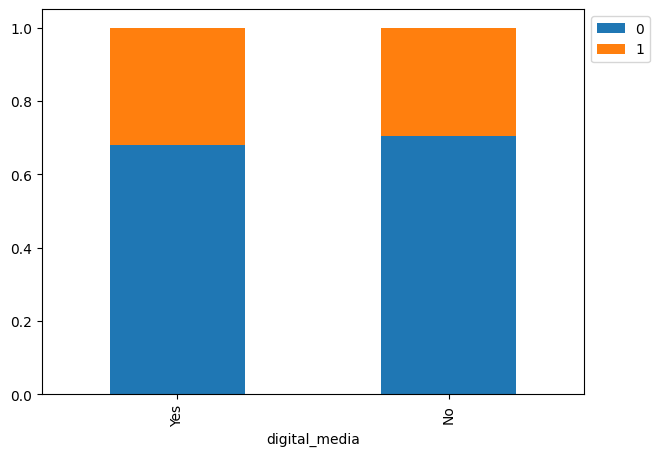

In [ ]:
stacked_barplot(data, "digital_media", "status") #for digital media

Leads who saw the ad on digital platforms had a higher conversion rate (168 out of 527, or 31.9%) compared to those who did not see the ad (1209 out of 4085, or 29.6%), suggesting that exposure to digital media has a slightly positive impact on lead conversion.

status                   0     1   All
educational_channels                  
All                   3235  1377  4612
No                    2727  1180  3907
Yes                    508   197   705
------------------------------------------------------------------------------------------------------------------------


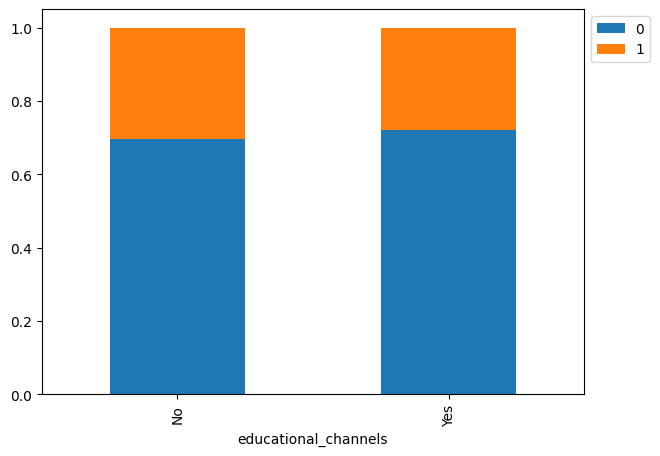

In [ ]:
stacked_barplot(data, "educational_channels", "status") #whether the lead heard about Extraalearn through educational channels and how does it impact the lead status

Leads who heard about ExtraaLearn through educational channels had a higher conversion rate (197 out of 705, or 27.9%) compared to those who did not hear through educational channels (1180 out of 3907, or 30.2%), indicating that educational channel exposure has a slightly lower conversion rate.

status       0     1   All
referral                  
All       3235  1377  4612
No        3205  1314  4519
Yes         30    63    93
------------------------------------------------------------------------------------------------------------------------


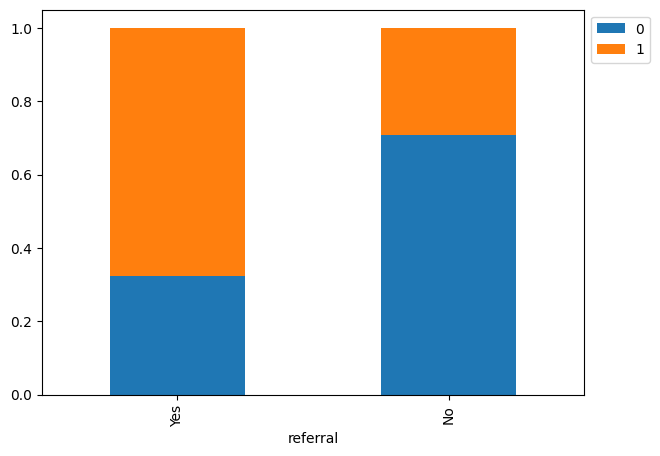

In [ ]:
stacked_barplot(data, "referral", "status") #whether the lead heard through a referral adn how does impact the lead status

Leads who were referred had a higher conversion rate (63 out of 93, or 67.7%) compared to those who were not referred (1314 out of 4519, or 29.1%), indicating that referrals significantly increase the likelihood of conversion.

# Checking Outliers in the data

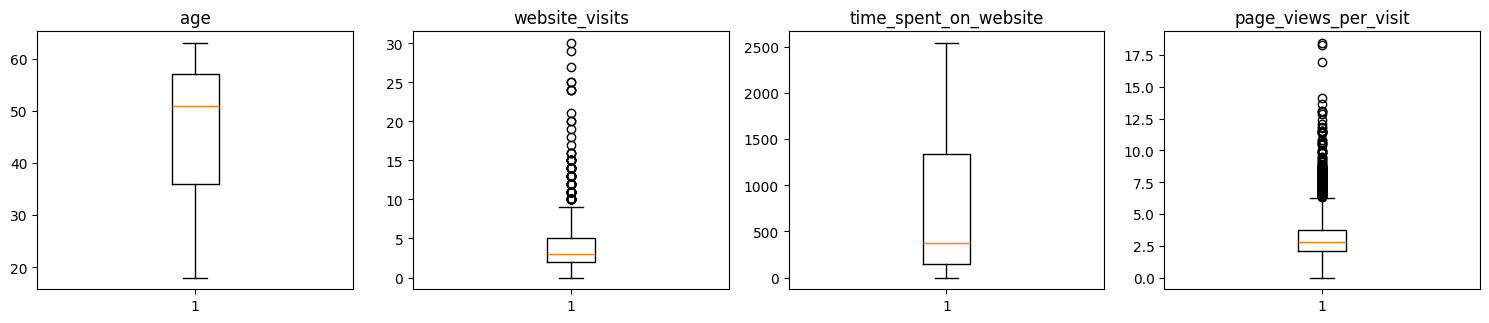

In [ ]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
# dropping release_year as it is a temporal variable
numeric_columns.remove("status")

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

The boxplots show significant outliers across multiple variables in the dataset. In website visits, there are numerous users visiting 10-30 times, far above the median of about 3 visits. The time spent on website shows extreme outliers reaching up to 2500 units (likely seconds or minutes), while most users spend under 500 units. Page views per visit has many outliers between 6-18 views, substantially exceeding the typical 2-3 pages viewed by most users. The age variable shows the least extreme outlier pattern. These outliers suggest a small segment of highly engaged users who visit much more frequently, spend considerably more time, and view significantly more pages than typical users.

# Data Preparation for Modeling

We want to predict which lead is more likely to be converted.

Before we proceed to build a model, we'll have to encode categorical features.

We'll split the data into train and test to be able to evaluate the model that we build on the train data.

In [ ]:
# Define the dependent (target) variable (status)
Y = data["status"]

# Drop 'status' from the features (X)
X = data.drop(["status"], axis=1)

# Encode categorical features in X by using pd.get_dummies to create dummy variables
X = pd.get_dummies(X, drop_first=True)

In [ ]:
# Splitting the data in a 70:30 ratio for train to test data
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1
)

In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3228, 16)
Shape of test set :  (1384, 16)
Percentage of classes in training set:
status
0   0.70415
1   0.29585
Name: proportion, dtype: float64
Percentage of classes in test set:
status
0   0.69509
1   0.30491
Name: proportion, dtype: float64


# Building Classification Models

**Model evaluation criterion**

**Model can make wrong predictions as:**

Predicting a lead will not be converted to a paid customer in reality, the lead would have converted to a paid customer.

Predicting a lead will be converted to a paid customer in reality, the lead would not have converted to a paid customer.

**Which case is more important?**

If we predict that a lead will not get converted and the lead would have converted then the company will lose a potential customer.

If we predict that a lead will get converted and the lead doesn't get converted the company might lose resources by nurturing false-positive cases.

Losing a potential customer is a greater loss.

How to reduce the losses?

Company would want Recall to be maximized, greater the Recall score higher are the chances of minimizing False Negatives.

**First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model**.

The model_performance_classification_statsmodels function will be used to check the model performance of models.
The confusion_matrix_statsmodels function will be used to plot the confusion matrix.

In [ ]:
# Function to print the classification report and get confusion matrix in a proper format

def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize = (8, 5))

    sns.heatmap(cm, annot = True,  fmt = '.2f', xticklabels = ['Not Converted', 'Converted'], yticklabels = ['Not Converted', 'Converted'])

    plt.ylabel('Actual')

    plt.xlabel('Predicted')

    plt.show()

# Decision Tree

**Building the decision tree model**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree classifier
d_tree = DecisionTreeClassifier(random_state=1)

# Fitting the model on the training data
d_tree.fit(X_train, y_train)

# To check the model's accuracy or perform further actions:
y_pred = d_tree.predict(X_test)

In [ ]:
# To check the model's performance
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.8128612716763006


This means that the model correctly predicted the target variable for approximately 81.29% of the test data. The accuracy is quite good, but it’s important to also consider other metrics (precision, recall, F1-score) to understand the model’s performance in more detail, especially when dealing with imbalanced classes.

In [ ]:
#For other metrics
# Make predictions on the test set
y_pred_test1 = d_tree.predict(X_test)  # Ensure you're using your trained model to predict on the test set

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_test1))

# Print the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test1))

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86       962
           1       0.69      0.70      0.70       422

    accuracy                           0.81      1384
   macro avg       0.78      0.78      0.78      1384
weighted avg       0.81      0.81      0.81      1384

Confusion Matrix:
[[829 133]
 [126 296]]


**Insights**

Class 0 (Not converted): The model is good at predicting class 0 with high precision (87%) and recall (86%), which means it's more likely to correctly predict leads that do not convert.

Class 1 (Converted): The model is less precise for class 1 (69%) but has a decent recall (70%), meaning it identifies 70% of the converted leads but makes a reasonable number of false positives (133 leads predicted as converted, but they weren't).

Overall, while the model performs well (81% accuracy), there is room for improvement in predicting class 1 (converted leads).

**Performing hyperparameter tuning with GridSearchCV to identify the optimal max_depth and help minimize overfitting in the model. We can also adjust other hyperparameters during this process.**

# Decision Tree - Hyperparameter Tuning

I am using the class_weight hyperparameter with the value equal to {0: 0.3, 1: 0.7} which is approximately the opposite of the imbalance in the original data.

Explanation: Class 0 (representing the "Not Converted" leads) is assigned a weight of 0.3.

Class 1 (representing the "Converted" leads) is assigned a weight of 0.7.

This is typically done, when there is class imbalance in the dataset. By assigning more weight to the minority class the model places more importance on correctly classifying the minority class, thus compensate for the imbalance and improving performance.


**This would tell the model that 1 is the important class here**.

In [ ]:
# Choose the type of classifier
d_tree_tuned = DecisionTreeClassifier(random_state = 7, class_weight = {0: 0.3, 1: 0.7})

# Grid of parameters to choose from
parameters = {'max_depth': np.arange(2, 10),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': [5, 10, 20, 25]
             }

# Type of scoring used to compare parameter combinations - recall score for class 1
scorer = metrics.make_scorer(recall_score, pos_label = 1)

# Run the grid search
grid_obj = GridSearchCV(d_tree_tuned, parameters, scoring = scorer, cv = 5)

grid_obj = grid_obj.fit(X_train, y_train)

# Set the classifier to the best combination of parameters
d_tree_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data
d_tree_tuned.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.3, 1: 0.7}, criterion='entropy',
                       max_depth=3, min_samples_leaf=5, random_state=7)

Explanation:

We used gini/entropy to measure the gini impurity. Lower entropy means the data is more pure after the split.

max_depth=3 this limits the maximum depth of the decision tree. This will prevent the tree from growing too deep and potentially overfitting the training data.

min_samples_leaf=5 minimum number of samples required to be at a leaf node. A value of 5 means that any node that has fewer than 5 samples will not bve allowed to split. This will prevent overfitting and ensure that the the leaves/final nodes dont have too mfew samples which could result in poor generalization and overfitting.

random_state=7 controls the randomness of the model, so to ensure the reproducitblity of the model. Will ensure that the results wont change each time the model is trained.

**Checking model performance on train and test set**

In [ ]:
# Checking performance on the training data
y_pred_train2 = d_tree.predict(X_train)  # Predicting on the training data

# Print classification report and confusion matrix for training data
from sklearn.metrics import classification_report, confusion_matrix

print("Training Data Classification Report:")
print(classification_report(y_train, y_pred_train2))

print("Training Data Confusion Matrix:")
print(confusion_matrix(y_train, y_pred_train2))

# Checking performance on the testing data
y_pred_test2 = d_tree.predict(X_test)  # Predicting on the test data

# Print classification report and confusion matrix for testing data
print("Test Data Classification Report:")
print(classification_report(y_test, y_pred_test2))

print("Test Data Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test2))

Training Data Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2273
           1       1.00      1.00      1.00       955

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228

Training Data Confusion Matrix:
[[2273    0]
 [   0  955]]
Test Data Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86       962
           1       0.69      0.70      0.70       422

    accuracy                           0.81      1384
   macro avg       0.78      0.78      0.78      1384
weighted avg       0.81      0.81      0.81      1384

Test Data Confusion Matrix:
[[829 133]
 [126 296]]


**Observations**

**Training Data Classification Report Interpretation:**
The classification report for the training data shows perfect performance, with an accuracy of 100% (1.00). Both precision, recall, and f1-score for class 0 (non-converted leads) and class 1 (converted leads) are also 1.00, indicating that the model correctly classified all leads in the training set. The confusion matrix also confirms this, showing that all 2273 non-converted leads (class 0) and all 955 converted leads (class 1) were correctly predicted without any misclassification. This suggests that the model has perfectly fit the training data, but it could indicate overfitting, as the performance is too ideal.

**Test Data Classification Report Interpretation:**
For the test data, the performance is slightly lower with an accuracy of 81%. The precision for class 0 (non-converted leads) is 0.87, meaning that when the model predicts a lead will not convert, it is correct 87% of the time. The recall for class 0 is 0.86, indicating that the model correctly identifies 86% of the non-converted leads. For class 1 (converted leads), the precision is 0.69, and the recall is 0.70, meaning the model is less effective at predicting converted leads, with a higher likelihood of false positives (predicting conversion when it does not happen). The confusion matrix shows that the model misclassified 133 non-converted leads as converted and 126 converted leads as non-converted. This indicates that while the model performs reasonably well on unseen data, there is room for improvement, particularly in predicting converted leads.

Note: The model will perform differently on unseen data, and while it may do well at predicting non-converted leads (with 87% precision), it’s less reliable at predicting converted leads, leading to an overall lower accuracy.

# Visualize the Decision Tree

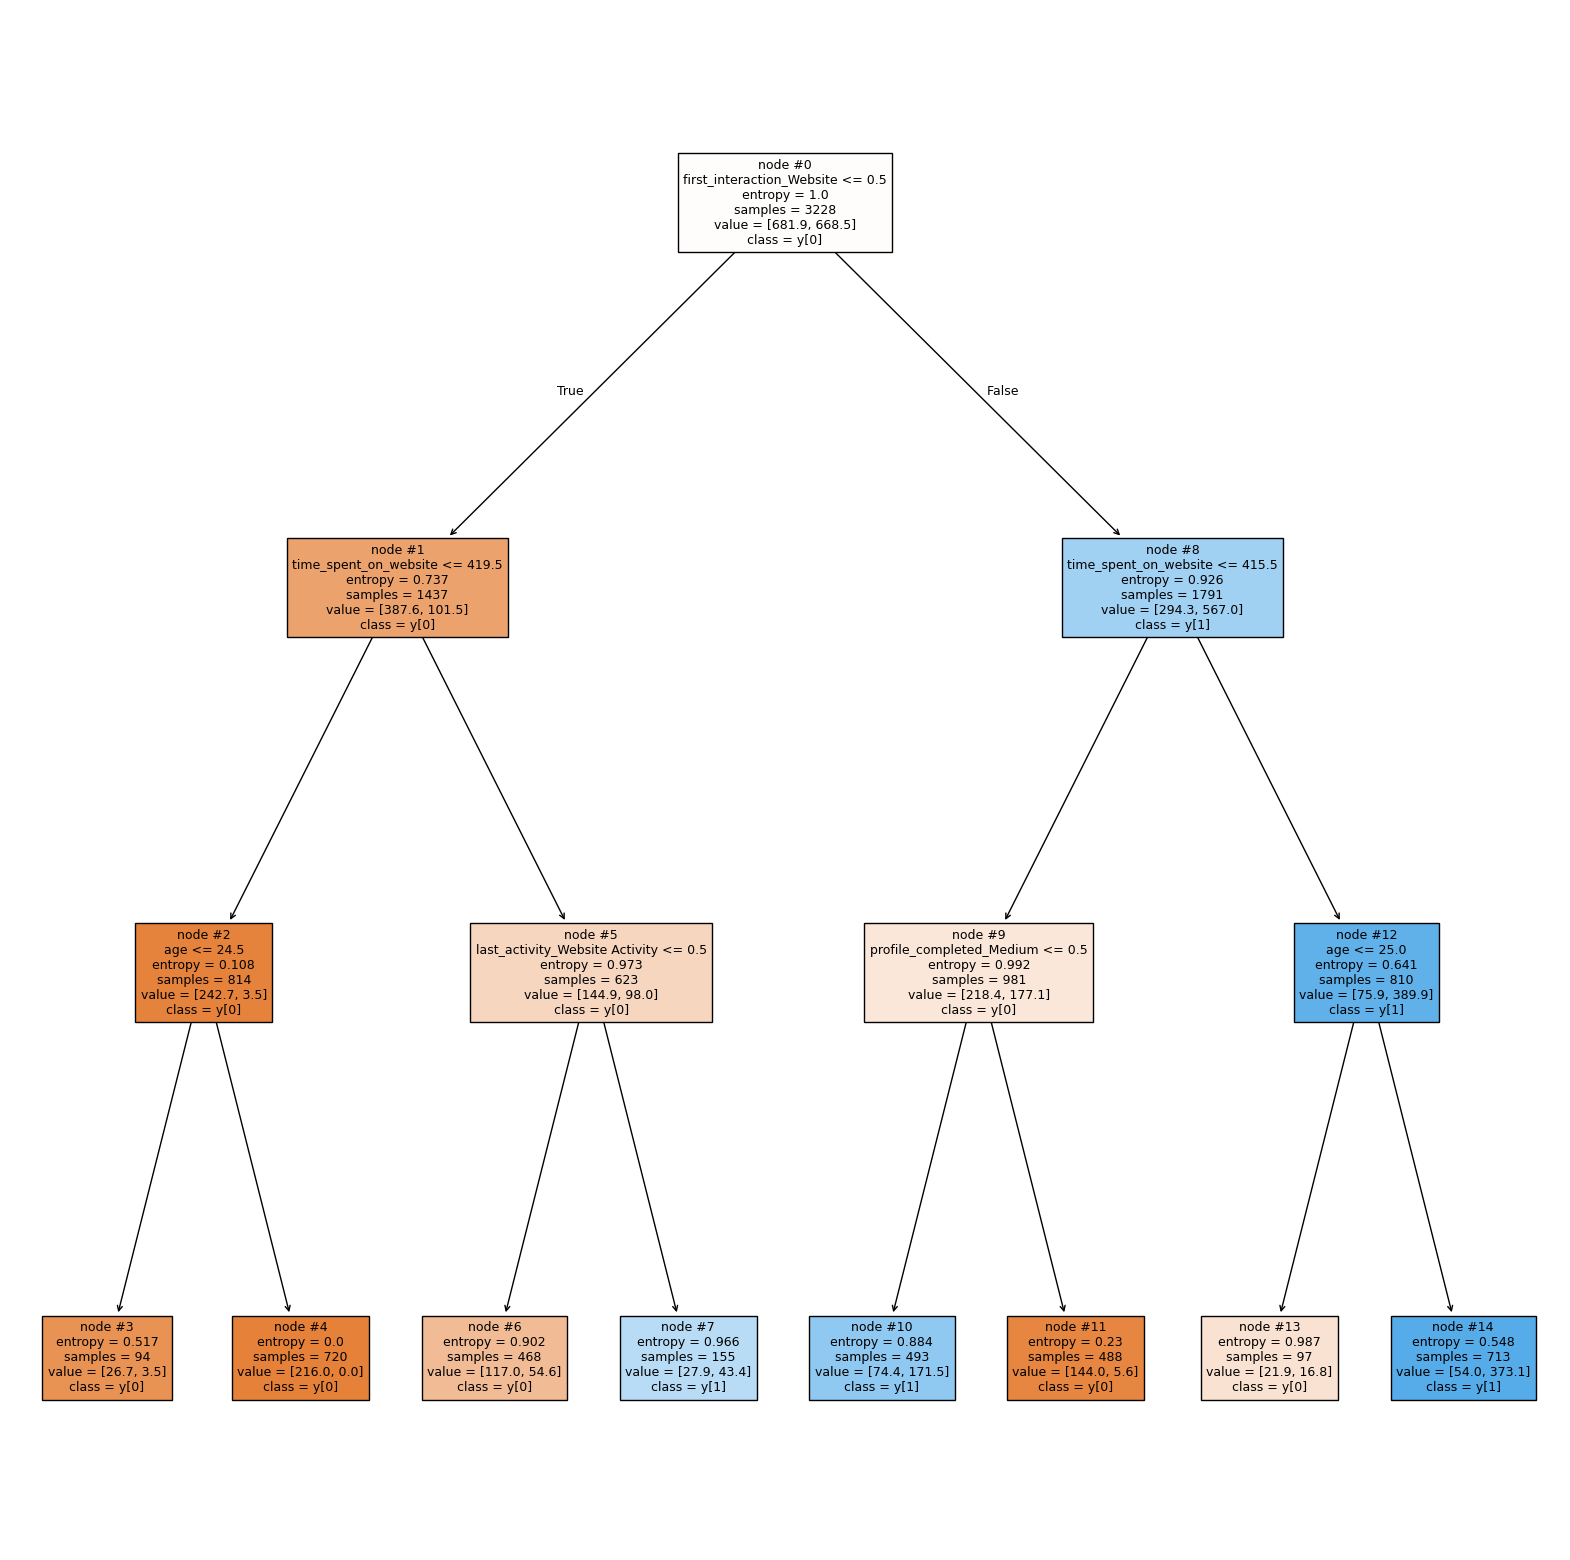

In [ ]:
features = list(X.columns)

plt.figure(figsize = (20, 20))

tree.plot_tree(d_tree_tuned, feature_names = features, filled = True, fontsize = 9, node_ids = True, class_names = True)

plt.show()

This decision tree shows website user classification based on engagement metrics. The primary split occurs on first interaction with the website (≤ 0.5), followed by time spent (≤ 419.5 or ≤ 415.5). The orange nodes represent class y[0] (likely non-converting users) while blue nodes represent y[1] (likely converting users). The model uses various metrics including time spent, age, profile completion, and last activity to make increasingly refined predictions, with entropy values decreasing at deeper levels, indicating better class separation.

Deeper Insights:

1.	Time spent on website is a critical factor for conversion - note how it appears at the second level of the tree for both branches, with different thresholds (419.5 and 415.5).
2.	Website activity metrics are more predictive for non-converters (orange nodes) - age, last activity, and profile completion all appear as splitting variables for these users.
3.	There's a purer classification in some leaf nodes (entropy = 0.0 in node #4) showing segments where prediction is nearly perfect, while others remain mixed.
4.	Sample distribution is unbalanced - there are more samples in the non-converting class (y[0]), suggesting either class imbalance in the dataset or that conversion is a relatively rare event.
5.	The tree structure suggests different user journeys to conversion, with distinct pathways for different user behaviors.

In [ ]:
# Importance of features in the tree building

print (pd.DataFrame(d_tree_tuned.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                                   Imp
time_spent_on_website          0.34814
first_interaction_Website      0.32718
profile_completed_Medium       0.23927
age                            0.06389
last_activity_Website Activity 0.02151
website_visits                 0.00000
page_views_per_visit           0.00000
current_occupation_Student     0.00000
current_occupation_Unemployed  0.00000
profile_completed_Low          0.00000
last_activity_Phone Activity   0.00000
print_media_type1_Yes          0.00000
print_media_type2_Yes          0.00000
digital_media_Yes              0.00000
educational_channels_Yes       0.00000
referral_Yes                   0.00000


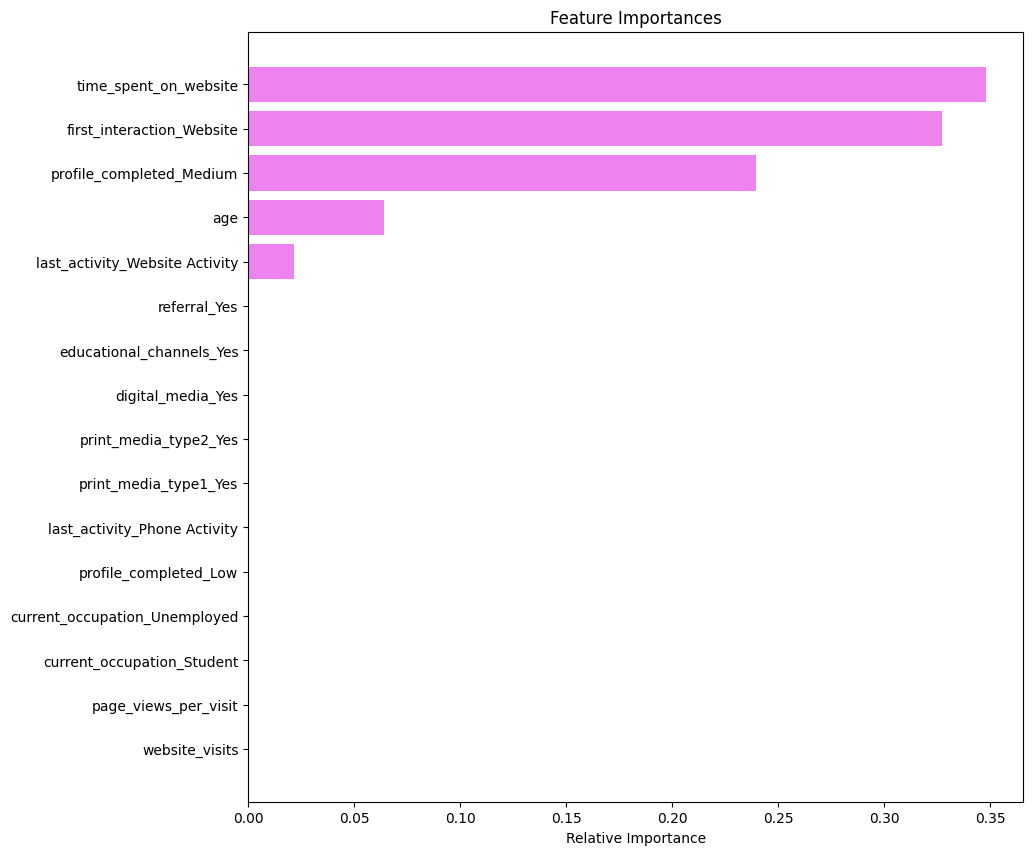

In [ ]:
# Plotting the feature importance
importances = d_tree_tuned.feature_importances_

indices = np.argsort(importances)

plt.figure(figsize = (10, 10))

plt.title('Feature Importances')

plt.barh(range(len(indices)), importances[indices], color = 'violet', align = 'center')

plt.yticks(range(len(indices)), [features[i] for i in indices])

plt.xlabel('Relative Importance')

plt.show()

Time spent on the website and first_interaction_website are the most important features followed by profile_completed, age, and last_activity.
The rest of the variables have no impact in this model, while deciding whether a lead will be converted or not.

# Random Forest Classifier

**Building Random Forest Model**

In [ ]:
# Fitting the random forest classifier on the training data
rf_estimator = RandomForestClassifier(n_estimators=100, random_state=7)

# Fit the model to the training data
rf_estimator.fit(X_train, y_train)

RandomForestClassifier(random_state=7)

In [ ]:
# Checking performance on the training data
y_pred_train3 = rf_estimator.predict(X_train)

print("Training Data Classification Report:")
print(classification_report(y_train, y_pred_train3))

print("Training Data Confusion Matrix:")
print(confusion_matrix(y_train, y_pred_train3))

Training Data Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2273
           1       1.00      1.00      1.00       955

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228

Training Data Confusion Matrix:
[[2273    0]
 [   0  955]]


The training data classification report shows that the Random Forest model has achieved perfect precision, recall, and F1-score of 1.00 for both classes (0 and 1). This indicates that the model is making flawless predictions on the training data. The confusion matrix further confirms this, with no misclassifications — all 2273 instances of class 0 and 955 instances of class 1 were correctly predicted. However, this perfect performance on the training set could indicate potential overfitting, as the model may be memorizing the data rather than generalizing well to unseen data.

In [ ]:
# Checking performance on the testing data
y_pred_test3 = rf_estimator.predict(X_test)

# Print classification report
print("Test Data Classification Report:")
print(classification_report(y_test, y_pred_test3))

# Print confusion matrix
print("Test Data Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test3))

Test Data Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.90       962
           1       0.80      0.69      0.74       422

    accuracy                           0.85      1384
   macro avg       0.84      0.81      0.82      1384
weighted avg       0.85      0.85      0.85      1384

Test Data Confusion Matrix:
[[889  73]
 [129 293]]


The test data classification report shows that the Random Forest model achieved an accuracy of 85%. For class 0 (non-converted leads), the model has a high precision of 0.87 and recall of 0.92, indicating that it is good at correctly identifying non-converted leads. For class 1 (converted leads), the model shows a lower precision of 0.80 and recall of 0.69, meaning it struggles a bit more to correctly identify converted leads but still performs reasonably well. The confusion matrix confirms that there are 889 true negatives, 293 true positives, 129 false negatives, and 73 false positives, indicating that the model is more effective at identifying non-converted leads than converted ones.

# Random Forest Classifier - Hyperparameter Tuning

Note: We will not tune the criterion hyperparameter as we know from hyperparameter tuning for decision trees that entropy is a better splitting criterion for this data.

In [ ]:
# Define the model and parameters grid
rf_estimator_tuned = RandomForestClassifier(criterion="entropy", random_state=7)

# Grid of parameters to choose from
parameters = {
    "n_estimators": [110, 120],
    "max_depth": [6, 7],
    "min_samples_leaf": [20, 25],
    "max_features": [0.8, 0.9],
    "max_samples": [0.9, 1],
    "class_weight": ["balanced", {0: 0.3, 1: 0.7}]
}

# Type of scoring used to compare parameter combinations - recall score for class 1
scorer = metrics.make_scorer(recall_score, pos_label=1)

# Run the grid search on the training data using scorer=scorer and cv=5
grid_obj = GridSearchCV(estimator=rf_estimator_tuned, param_grid=parameters, scoring=scorer, cv=5)

# Fit the grid search to the training data
grid_obj.fit(X_train, y_train)

# Save the best estimator to variable rf_estimator_tuned
rf_estimator_tuned = grid_obj.best_estimator_

In [ ]:
# Fitting the best algorithm (tuned Random Forest) to the training data
rf_estimator_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=6, max_features=0.8, max_samples=0.9,
                       min_samples_leaf=25, n_estimators=120, random_state=7)

In [ ]:
# Checking performance on the training data
y_pred_train4 = rf_estimator_tuned.predict(X_train)

#Print the classification report and confusion matrix for training data
print("Training Data Classification Report:")
print(classification_report(y_train, y_pred_train4))

print("Training Data Confusion Matrix:")
print(confusion_matrix(y_train, y_pred_train4))

Training Data Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      2273
           1       0.68      0.87      0.76       955

    accuracy                           0.84      3228
   macro avg       0.81      0.85      0.82      3228
weighted avg       0.86      0.84      0.84      3228

Training Data Confusion Matrix:
[[1876  397]
 [ 121  834]]


The training data classification report shows that the tuned Random Forest model has an accuracy of 84%. For class 0 (leads not converted), the precision is 0.94 and the recall is 0.83, indicating that the model is good at identifying the majority class but may miss some of them. For class 1 (leads converted), the precision is 0.68 and recall is 0.87, indicating a stronger ability to capture positive class instances (converted leads) but with some false positives. The confusion matrix reflects 1876 true negatives, 397 false positives, 121 false negatives, and 834 true positives, demonstrating that the model performs well in identifying both classes but with room for improvement in balancing false positives and false negatives.

In [ ]:
# Checking performance on the test data
y_pred_test4 = rf_estimator_tuned.predict(X_test)

print("Test Data Classification Report:")
print(classification_report(y_test, y_pred_test4))

print("Test Data Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test4))

Test Data Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.87       962
           1       0.68      0.85      0.76       422

    accuracy                           0.83      1384
   macro avg       0.81      0.84      0.82      1384
weighted avg       0.85      0.83      0.84      1384

Test Data Confusion Matrix:
[[795 167]
 [ 62 360]]


The test data classification report shows that the model has an accuracy of 83%. For class 0 (leads that did not convert), the precision is 0.93 and the recall is 0.83, meaning the model is good at correctly identifying non-converted leads but misses some of them. For class 1 (leads that converted), the precision is 0.68 and recall is 0.85, indicating the model is better at identifying converted leads (higher recall) but is less precise (more false positives). The confusion matrix confirms this, with 795 true negatives (correctly identified non-converted leads) and 360 true positives (correctly identified converted leads), while there are 167 false positives and 62 false negatives.

Note: One of the drawbacks of ensemble models is that we lose the ability to obtain an interpretation of the model. We cannot observe the decision rules for random forests the way we did for decision trees. So, let's just check the feature importance of the model.

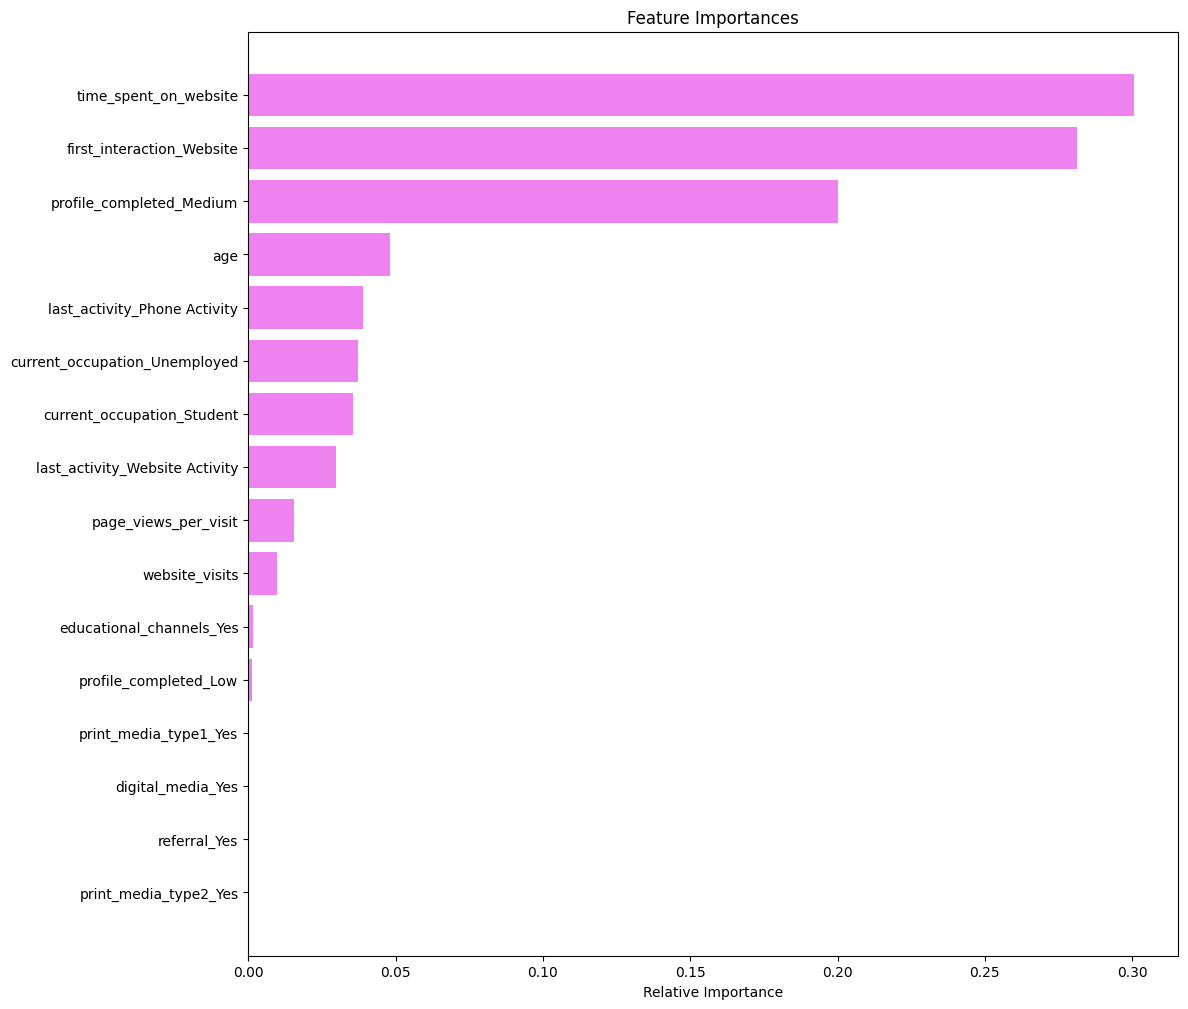

In [ ]:
importances = rf_estimator_tuned.feature_importances_

indices = np.argsort(importances)

feature_names = list(X.columns)

plt.figure(figsize = (12, 12))

plt.title('Feature Importances')

plt.barh(range(len(indices)), importances[indices], color = 'violet', align = 'center')

plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

plt.xlabel('Relative Importance')

plt.show()

Similar to the decision tree model, time spent on website, first_interaction_website, profile_completed, and age are the top four features that help distinguish between not converted and converted leads.

Unlike the decision tree, the random forest gives some importance to other variables like occupation, page_views_per_visit, as well. This implies that the random forest is giving importance to more factors in comparison to the decision tree.

# Comparison of Decision Tree Model with Random Forest Model from Analysis

**Decision Tree:**

It performed well on the training data, achieving perfect classification (accuracy = 100%), but the performance on the test data showed a significant drop (accuracy around 81%). This indicates overfitting, as the model learned very well from the training data but struggled to generalize to new, unseen data.

It also displayed high precision and recall for class 0 (not converted) and class 1 (converted), but its decision-making process was limited to only the top four features.

**Random Forest:**

The Random Forest model had more balanced performance, with an accuracy of 83% on the test data. It did better at generalizing than the decision tree, with fewer signs of overfitting.
It leveraged more features for classification, showing higher flexibility and better handling of the data complexity compared to the decision tree. This suggests that Random Forest is a more versatile model, considering a larger set of features to make decisions, which can lead to better predictive performance when dealing with real-world data.

**Which model to choose?**

Random Forest demonstrated better generalization (83% accuracy vs. 81% accuracy on the test set) and considered more features to make predictions, it is likely the better model in this scenario. However, the best model depends on the specific application and trade-offs between model complexity and interpretability. If interpretability and simplicity are more important, then the Decision Tree might be preferable. But if overall performance is the priority, the Random Forest seems like the more reliable choice.

# Conclusion

**Analyze and build an ML model to help identify which leads are more likely to convert to paid customers:**

We used machine learning models like Decision Tree and Random Forest to analyze and predict which leads are more likely to convert into paid customers. These models were trained on historical data containing features such as age, occupation, time spent on the website, page views per visit, profile completion, and first interaction type. After evaluating these models, it was found that Random Forest performed slightly better in predicting conversions with an accuracy of 83%. The model can now predict the likelihood of a lead converting to a paid customer based on these features, helping businesses prioritize high-potential leads for further engagement.

**Find the factors driving the lead conversion process:**

The Random Forest model provided insights into the most important features influencing lead conversion. The factors that have the highest importance are time spent on the website, first interaction type (especially website interaction), profile completion, and age. These features were consistently identified across different models as key drivers. Additionally, other factors like occupation and page views per visit were also found to have some importance, indicating that leads who engage more with the website, have completed their profiles, and are more mature in age are more likely to convert. These findings can guide businesses to focus on improving lead engagement on the website, encouraging profile completion, and tailoring marketing strategies based on age or occupation.

**Create a profile of the leads which are likely to convert:**

Leads that are likely to convert to paid customers can be described by several key characteristics identified through the models. These leads typically spend more time on the website and engage more with the platform (e.g., through multiple page views per visit). They also tend to have completed their profiles, showing genuine interest in the service. Age is another factor, with older leads (or those in a certain age bracket) being more likely to convert. Additionally, leads that interacted with the website (as opposed to other channels) during their first interaction have a higher conversion likelihood. By focusing on these characteristics, business can better profile and target leads with higher conversion potential, improving the sales and marketing strategies.

# Business Reccomendations for ExtraaLearn

- Prioritize High-Engagement Leads: Allocate resources towards leads that spend more time on the website and have higher page views per visit. These leads show greater interest in your programs and are more likely to convert.

- Focus on Leads with Completed Profiles: Engage more actively with leads who
have completed their profiles. This indicates stronger intent to enroll, and they are more likely to convert into paid customers.

- Target Leads from Website Interactions: Leads that first interact with the company via the website should be prioritized. These leads are more likely to convert compared to those who first interact through other channels.

- Age Group Targeting: Leads in a certain age bracket (older or professional groups) appear to convert at a higher rate. Tailor marketing strategies to target these segments more effectively.

- Optimized Follow-Ups for Occupation-Specific Leads: Leads from certain occupations, like professionals looking to upskill or reskill, tend to show a higher conversion rate. Implement personalized communication and resources based on occupation.

- Use Data-Driven Marketing for Lead Nurturing: Invest more heavily in nurturing campaigns for leads that engage early (i.e., website visits and brochure downloads). These leads are likely in the consideration phase and can be converted with proper follow-ups.

- Focus on High-Recall Channels: Channels such as email and the website where engagement is higher should receive more follow-up from sales teams, as these have higher conversion potential.